<a href="https://colab.research.google.com/github/raju-cse/Flyrank-internship_ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import duckdb

hf_token = "HF_TOKEN"

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
result = con.sql(f"SELECT COUNT(*) FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')")
print(result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     78835655 │
└──────────────┘



In [ ]:
# Check schema of the main fact table
schema = con.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
""")
print(schema)

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

In [ ]:
# Preview first 5 rows
sample = con.sql(f"""
    SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
    LIMIT 5
""").df()
sample

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
info = api.dataset_info("FlyRank/internship-warehouse")

folders = set()
for sibling in info.siblings:
    folders.add(sibling.rfilename.split('/')[0])

print(sorted(folders))

['.gitattributes', 'README.md', 'dim_clients.parquet', 'dim_content.parquet', 'fact_content_daily_performance', 'fact_content_daily_performance_sample.parquet', 'fact_content_query_90d.parquet']


In [ ]:
# Show ALL columns, not truncated
schema_full = con.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
""").df()

import pandas as pd
pd.set_option('display.max_rows', None)
print(schema_full)

                 column_name column_type null   key default extra
0                report_date        DATE  YES  None    None  None
1             client_hash_id     VARCHAR  YES  None    None  None
2            content_hash_id     VARCHAR  YES  None    None  None
3             client_has_gsc     BOOLEAN  YES  None    None  None
4             client_has_ga4     BOOLEAN  YES  None    None  None
5         gsc_data_available     BOOLEAN  YES  None    None  None
6         ga4_data_available     BOOLEAN  YES  None    None  None
7            gsc_impressions      BIGINT  YES  None    None  None
8                 gsc_clicks      BIGINT  YES  None    None  None
9           gsc_sum_position      BIGINT  YES  None    None  None
10          gsc_avg_position      DOUBLE  YES  None    None  None
11             ga4_pageviews      BIGINT  YES  None    None  None
12              ga4_sessions      BIGINT  YES  None    None  None
13                 ga4_users      BIGINT  YES  None    None  None
14      ga

In [ ]:
# dim_content columns
schema_content = con.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{rel}/dim_content.parquet')
""").df()
print("=== dim_content ===")
print(schema_content)

# dim_clients columns
schema_clients = con.sql(f"""
    DESCRIBE SELECT * FROM read_parquet('{rel}/dim_clients.parquet')
""").df()
print("=== dim_clients ===")
print(schema_clients)

=== dim_content ===
                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keyword_char_count      BIGINT  YES  None    None  None
5          keyword_token_count      BIGINT  YES  None    None  None
6               url_char_count      BIGINT  YES  None    None  None
7         content_created_date        DATE  YES  None    None  None
8         content_updated_date        DATE  YES  None    None  None
9                 content_type     VARCHAR  YES  None    None  None
10               search_volume      BIGINT  YES  None    None  None
11                 competition      DOUBLE  YES  None    None  None
12           competition_level     VARCHAR  YES  None    None  None
13                         c

In [ ]:
# Aggregate fact table to monthly level per content
monthly_perf = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        month,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_sec,
        SUM(sessions_ai) AS ai_sessions,
        SUM(scroll_events) AS scroll_events
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
    GROUP BY client_hash_id, content_hash_id, month
    ORDER BY content_hash_id, month
""").df()

print(monthly_perf.shape)
monthly_perf.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(2871202, 11)


,client_hash_id,content_hash_id,month,impressions,clicks,avg_position,sessions,engaged_sessions,engagement_sec,ai_sessions,scroll_events
0,client_9958f0a7ae1df715,content_000005d4ced12088,2025-03,7.0,0.0,9.333333,0.0,0.0,0.0,0.0,0.0
1,client_9958f0a7ae1df715,content_000005d4ced12088,2025-04,146.0,1.0,35.762918,0.0,0.0,0.0,0.0,0.0
2,client_9958f0a7ae1df715,content_000005d4ced12088,2025-05,257.0,0.0,38.982641,0.0,0.0,0.0,0.0,0.0
3,client_9958f0a7ae1df715,content_000005d4ced12088,2025-06,139.0,0.0,37.522978,0.0,0.0,0.0,0.0,0.0
4,client_9958f0a7ae1df715,content_000005d4ced12088,2025-07,254.0,0.0,35.843110,0.0,0.0,0.0,0.0,0.0
5,client_9958f0a7ae1df715,content_000005d4ced12088,2025-08,742.0,1.0,39.317181,0.0,0.0,0.0,0.0,0.0
6,client_9958f0a7ae1df715,content_000005d4ced12088,2025-09,524.0,1.0,37.794280,0.0,0.0,0.0,0.0,0.0
7,client_9958f0a7ae1df715,content_000005d4ced12088,2025-10,197.0,0.0,36.865622,0.0,0.0,0.0,0.0,0.0
8,client_9958f0a7ae1df715,content_000005d4ced12088,2025-11,120.0,0.0,38.651264,3.0,0.0,0.0,0.0,0.0
9,client_9958f0a7ae1df715,content_000005d4ced12088,2025-12,184.0,0.0,38.919439,0.0,0.0,0.0,0.0,0.0


In [ ]:
month_range = con.sql(f"""
    SELECT MIN(month) AS min_month, MAX(month) AS max_month, COUNT(DISTINCT month) AS num_months
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
""").df()
print(month_range)

  min_month max_month  num_months
0   2025-01   2026-06          18


In [ ]:
# Feature window: past 12 months (2025-01 to 2025-12)
feature_window = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_past,
        SUM(gsc_clicks) AS clicks_past,
        AVG(gsc_avg_position) AS avg_position_past,
        SUM(ga4_sessions) AS sessions_past,
        SUM(ga4_engaged_sessions) AS engaged_sessions_past,
        SUM(sessions_ai) AS ai_sessions_past,
        -- First half vs second half trend within the feature window
        SUM(CASE WHEN month <= '2025-06' THEN gsc_impressions ELSE 0 END) AS impressions_h1,
        SUM(CASE WHEN month > '2025-06' THEN gsc_impressions ELSE 0 END) AS impressions_h2
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
    WHERE month BETWEEN '2025-01' AND '2025-12'
    GROUP BY client_hash_id, content_hash_id
""").df()

print(feature_window.shape)
feature_window.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(255486, 10)


,client_hash_id,content_hash_id,impressions_past,clicks_past,avg_position_past,sessions_past,engaged_sessions_past,ai_sessions_past,impressions_h1,impressions_h2
0,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,832.0,2.0,39.878109,0.0,0.0,0.0,634.0,198.0
1,client_9958f0a7ae1df715,content_b4462a1b90640058,8253.0,15.0,17.341701,31.0,1.0,0.0,803.0,7450.0
2,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,11678.0,35.0,38.611572,11.0,1.0,0.0,4743.0,6935.0
3,client_9958f0a7ae1df715,content_89c6c2e17e412e20,5860.0,29.0,26.471851,20.0,1.0,0.0,2213.0,3647.0
4,client_9958f0a7ae1df715,content_8a3ccd5a0b61b7f7,8475.0,73.0,26.838953,16.0,0.0,2.0,4961.0,3514.0


In [ ]:
# Label window: future 6 months (2026-01 to 2026-06)
label_window = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_future,
        SUM(gsc_clicks) AS clicks_future,
        AVG(gsc_avg_position) AS avg_position_future
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
    WHERE month BETWEEN '2026-01' AND '2026-06'
    GROUP BY client_hash_id, content_hash_id
""").df()

print(label_window.shape)
label_window.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(427292, 5)


,client_hash_id,content_hash_id,impressions_future,clicks_future,avg_position_future
0,client_e547b89c05043229,content_cc02e6a397d2ffc2,12543.0,50.0,7.137197
1,client_e547b89c05043229,content_52d68cbbd7862053,11126.0,32.0,12.850682
2,client_e547b89c05043229,content_782d0c9cd351dcb4,13841.0,138.0,13.791638
3,client_e547b89c05043229,content_7916e8f527f1c672,2001.0,2.0,35.454892
4,client_e547b89c05043229,content_e79bcd3d80e36f91,3167.0,3.0,30.931937


In [ ]:
import pandas as pd

# Join feature window with label window on content_hash_id
merged = feature_window.merge(
    label_window[['content_hash_id', 'impressions_future', 'clicks_future', 'avg_position_future']],
    on='content_hash_id',
    how='inner'  # only keep content that exists in both windows
)

print(merged.shape)
merged.head()

(255486, 13)


,client_hash_id,content_hash_id,impressions_past,clicks_past,avg_position_past,sessions_past,engaged_sessions_past,ai_sessions_past,impressions_h1,impressions_h2,impressions_future,clicks_future,avg_position_future
0,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,832.0,2.0,39.878109,0.0,0.0,0.0,634.0,198.0,13.0,0.0,39.125000
1,client_9958f0a7ae1df715,content_b4462a1b90640058,8253.0,15.0,17.341701,31.0,1.0,0.0,803.0,7450.0,330.0,0.0,62.734475
2,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,11678.0,35.0,38.611572,11.0,1.0,0.0,4743.0,6935.0,1511.0,1.0,69.298516
3,client_9958f0a7ae1df715,content_89c6c2e17e412e20,5860.0,29.0,26.471851,20.0,1.0,0.0,2213.0,3647.0,225.0,1.0,49.881640
4,client_9958f0a7ae1df715,content_8a3ccd5a0b61b7f7,8475.0,73.0,26.838953,16.0,0.0,2.0,4961.0,3514.0,856.0,0.0,54.922581


In [ ]:
# Calculate % change from past to future
merged['impressions_pct_change'] = (
    (merged['impressions_future'] - merged['impressions_past']) /
    merged['impressions_past'].replace(0, pd.NA)
) * 100

# Define label thresholds (you can tune these)
def label_content(pct_change):
    if pd.isna(pct_change):
        return 'insufficient_data'
    elif pct_change >= 20:
        return 'growing'
    elif pct_change <= -20:
        return 'declining'
    else:
        return 'stable'

merged['label'] = merged['impressions_pct_change'].apply(label_content)

print(merged['label'].value_counts())
merged.head()

label
insufficient_data    126563
growing               86123
declining             33181
stable                 9619
Name: count, dtype: int64


,client_hash_id,content_hash_id,impressions_past,clicks_past,avg_position_past,sessions_past,engaged_sessions_past,ai_sessions_past,impressions_h1,impressions_h2,impressions_future,clicks_future,avg_position_future,impressions_pct_change,label
0,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,832.0,2.0,39.878109,0.0,0.0,0.0,634.0,198.0,13.0,0.0,39.125000,-98.4375,declining
1,client_9958f0a7ae1df715,content_b4462a1b90640058,8253.0,15.0,17.341701,31.0,1.0,0.0,803.0,7450.0,330.0,0.0,62.734475,-96.001454,declining
2,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,11678.0,35.0,38.611572,11.0,1.0,0.0,4743.0,6935.0,1511.0,1.0,69.298516,-87.061141,declining
3,client_9958f0a7ae1df715,content_89c6c2e17e412e20,5860.0,29.0,26.471851,20.0,1.0,0.0,2213.0,3647.0,225.0,1.0,49.881640,-96.16041,declining
4,client_9958f0a7ae1df715,content_8a3ccd5a0b61b7f7,8475.0,73.0,26.838953,16.0,0.0,2.0,4961.0,3514.0,856.0,0.0,54.922581,-89.899705,declining


In [ ]:
# Normalize by number of months in each window to get fair comparison
merged['impressions_monthly_avg_past'] = merged['impressions_past'] / 12
merged['impressions_monthly_avg_future'] = merged['impressions_future'] / 6

# Recalculate % change using monthly averages (fair, apples-to-apples)
merged['impressions_pct_change'] = (
    (merged['impressions_monthly_avg_future'] - merged['impressions_monthly_avg_past']) /
    merged['impressions_monthly_avg_past'].replace(0, pd.NA)
) * 100

# Re-apply labeling
merged['label'] = merged['impressions_pct_change'].apply(label_content)

print(merged['label'].value_counts())
merged[['content_hash_id', 'impressions_monthly_avg_past', 'impressions_monthly_avg_future', 'impressions_pct_change', 'label']].head(10)

label
insufficient_data    126563
growing              100042
declining             24373
stable                 4508
Name: count, dtype: int64


,content_hash_id,impressions_monthly_avg_past,impressions_monthly_avg_future,impressions_pct_change,label
0,content_fe8e8155ce1d47a2,69.333333,2.166667,-96.875,declining
1,content_b4462a1b90640058,687.750000,55.000000,-92.002908,declining
2,content_c782fa8abd4fce5e,973.166667,251.833333,-74.122281,declining
3,content_89c6c2e17e412e20,488.333333,37.500000,-92.320819,declining
4,content_8a3ccd5a0b61b7f7,706.250000,142.666667,-79.79941,declining
5,content_d39ef5d4aa3d73de,619.416667,64.666667,-89.56007,declining
6,content_73d0d66253d25ab9,741.500000,63.500000,-91.436278,declining
7,content_eebfb2913c3a0eaf,1224.833333,120.333333,-90.175534,declining
8,content_63c7a1498f76797f,677.583333,0.166667,-99.975403,declining
9,content_519c6ac7943e296b,67.333333,6.666667,-90.09901,declining


In [ ]:
# Check total impressions per month across ALL content — spot any incomplete months
monthly_totals = con.sql(f"""
    SELECT
        month,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        COUNT(DISTINCT content_hash_id) AS distinct_content
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
    GROUP BY month
    ORDER BY month
""").df()

print(monthly_totals)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      month  total_impressions  total_clicks  distinct_content
0   2025-01            13853.0         108.0               476
1   2025-02          1195015.0        7823.0              5903
2   2025-03          3847103.0       26138.0             10374
3   2025-04          8843940.0       52974.0             13046
4   2025-05         14454515.0       70374.0             14887
5   2025-06         16930659.0       70245.0             16399
6   2025-07         20298448.0       84676.0             27945
7   2025-08         29289942.0      119373.0             37204
8   2025-09         37726329.0      176130.0             53127
9   2025-10         55073098.0      274631.0            110339
10  2025-11         83871948.0      341306.0            251384
11  2025-12        112406941.0      359302.0            254621
12  2026-01        144354689.0      476140.0            261984
13  2026-02        180128922.0      586205.0            321546
14  2026-03        280657589.0      821832.0           

In [ ]:
# Fetch content metadata
content_meta = con.sql(f"""
    SELECT
        content_hash_id,
        content_created_date,
        content_updated_date,
        last_optimized_date,
        optimization_eligible_date,
        content_type,
        word_count,
        search_volume,
        competition,
        main_intent,
        is_published,
        is_deleted
    FROM read_parquet('{rel}/dim_content.parquet')
""").df()

print(content_meta.shape)
content_meta.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(519606, 12)


,content_hash_id,content_created_date,content_updated_date,last_optimized_date,optimization_eligible_date,content_type,word_count,search_volume,competition,main_intent,is_published,is_deleted
0,content_004de9653278b5a4,2026-05-30,2026-07-01,NaT,NaT,keyword article,2555,30,0.91,transactional,True,False
1,content_00dc5efae381b2ab,2026-06-12,2026-07-01,NaT,NaT,keyword article,2430,10,0.00,commercial,True,False
2,content_01410f2556c327ac,2026-05-09,2026-07-01,NaT,NaT,keyword article,2645,480,0.36,informational,True,False
3,content_019f27f634053ca7,2026-06-15,2026-06-15,NaT,NaT,keyword article,2522,0,0.00,transactional,True,False
4,content_01efa71faea45dcc,2026-05-21,2026-06-01,NaT,NaT,keyword article,2552,2400,0.70,transactional,True,False


In [ ]:
# Join with our merged dataset
merged_full = merged.merge(content_meta, on='content_hash_id', how='left')

# Calculate content age (in days) as of the feature window end (2025-12-31)
import pandas as pd
merged_full['content_created_date'] = pd.to_datetime(merged_full['content_created_date'])
cutoff = pd.Timestamp('2025-12-31')
merged_full['content_age_days'] = (cutoff - merged_full['content_created_date']).dt.days

# Compare average age by label
print(merged_full.groupby('label')['content_age_days'].mean())

label
declining            182.448857
growing              161.734452
insufficient_data    169.515585
stable               178.872671
Name: content_age_days, dtype: float64


In [ ]:
# Filter out insufficient_data rows
model_df = merged_full[merged_full['label'] != 'insufficient_data'].copy()
print(model_df.shape)
print(model_df['label'].value_counts())

(128923, 29)
label
growing      100042
declining     24373
stable         4508
Name: count, dtype: int64


In [ ]:
import numpy as np

# Trend within past window (H1 vs H2) - is it already trending up or down before the future window?
model_df['h1_h2_ratio'] = model_df['impressions_h2'] / model_df['impressions_h1'].replace(0, np.nan)

# CTR (click-through rate) as engagement quality signal
model_df['ctr_past'] = model_df['clicks_past'] / model_df['impressions_past'].replace(0, np.nan)

# Days since last optimization (if never optimized, use content age instead)
model_df['last_optimized_date'] = pd.to_datetime(model_df['last_optimized_date'])
model_df['days_since_optimized'] = (pd.Timestamp('2025-12-31') - model_df['last_optimized_date']).dt.days
model_df['days_since_optimized'] = model_df['days_since_optimized'].fillna(model_df['content_age_days'])

# Fill remaining NaNs in engineered features
model_df['h1_h2_ratio'] = model_df['h1_h2_ratio'].fillna(0)
model_df['ctr_past'] = model_df['ctr_past'].fillna(0)

print(model_df[['content_age_days', 'h1_h2_ratio', 'ctr_past', 'days_since_optimized']].describe())

       content_age_days    h1_h2_ratio       ctr_past  days_since_optimized
count     128923.000000  128923.000000  128923.000000          128923.00000
mean         166.249793       2.076221       0.006809              95.38554
std           84.241192      88.914127       0.047525             150.82415
min          -65.000000       0.000000       0.000000            -187.00000
25%          115.000000       0.000000       0.000000              30.00000
50%          153.000000       0.000000       0.000000             136.00000
75%          197.000000       0.000000       0.002562             175.00000
max          397.000000   25967.000000       1.000000             397.00000


In [ ]:
feature_cols = [
    'impressions_past', 'clicks_past', 'avg_position_past',
    'sessions_past', 'engaged_sessions_past', 'ai_sessions_past',
    'h1_h2_ratio', 'ctr_past', 'content_age_days', 'days_since_optimized',
    'word_count', 'search_volume', 'competition'
]

X = model_df[feature_cols].fillna(0)
y = model_df['label']

print(X.shape, y.shape)
print(X.isna().sum())

(128923, 13) (128923,)
impressions_past         0
clicks_past              0
avg_position_past        0
sessions_past            0
engaged_sessions_past    0
ai_sessions_past         0
h1_h2_ratio              0
ctr_past                 0
content_age_days         0
days_since_optimized     0
word_count               0
search_volume            0
competition              0
dtype: int64


In [ ]:
# Check negative content_age_days
print("Negative age count:", (model_df['content_age_days'] < 0).sum())

# Clip content_age_days at 0 (can't be negative)
model_df['content_age_days'] = model_df['content_age_days'].clip(lower=0)

# Clip h1_h2_ratio at a reasonable upper bound (e.g., 99th percentile) to reduce outlier influence
cap = model_df['h1_h2_ratio'].quantile(0.99)
print("99th percentile cap:", cap)
model_df['h1_h2_ratio'] = model_df['h1_h2_ratio'].clip(upper=cap)

# Rebuild X with cleaned features
X = model_df[feature_cols].fillna(0)
y = model_df['label']

print(X.describe())

Negative age count: 2
99th percentile cap: 21.364180790960408
       impressions_past    clicks_past  avg_position_past  sessions_past  \
count      1.289230e+05  128923.000000      128923.000000  128923.000000   
mean       2.978148e+03      12.279267          17.236625       3.395376   
std        1.351087e+04      81.387901          18.660785      37.002891   
min        1.000000e+00       0.000000           0.000000       0.000000   
25%        1.000000e+01       0.000000           5.500000       0.000000   
50%        1.480000e+02       0.000000           9.091824       0.000000   
75%        1.304000e+03       2.000000          21.820594       0.000000   
max        1.036572e+06    9698.000000         292.000000    6723.000000   

       engaged_sessions_past  ai_sessions_past    h1_h2_ratio       ctr_past  \
count          128923.000000     128923.000000  128923.000000  128923.000000   
mean                0.232433          0.055529       0.599390       0.006809   
std          

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = model_df['client_hash_id']

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts(normalize=True))
print("Test label distribution:\n", y_test.value_counts(normalize=True))

Train size: (92332, 13)
Test size: (36591, 13)
Train label distribution:
 label
growing      0.765780
declining    0.196432
stable       0.037788
Name: proportion, dtype: float64
Test label distribution:
 label
growing      0.801727
declining    0.170424
stable       0.027848
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Baseline: always predict the majority class
majority_class = y_train.value_counts().idxmax()
baseline_preds = [majority_class] * len(y_test)

print("Baseline (majority class):", majority_class)
print("Baseline accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds, zero_division=0))

Baseline (majority class): growing
Baseline accuracy: 0.8017272006777623
              precision    recall  f1-score   support

   declining       0.00      0.00      0.00      6236
     growing       0.80      1.00      0.89     29336
      stable       0.00      0.00      0.00      1019

    accuracy                           0.80     36591
   macro avg       0.27      0.33      0.30     36591
weighted avg       0.64      0.80      0.71     36591



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',  # since classes are imbalanced (growing >> declining >> stable)
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds, zero_division=0))

Random Forest accuracy: 0.6807684949851056
              precision    recall  f1-score   support

   declining       0.41      0.26      0.32      6236
     growing       0.87      0.77      0.82     29336
      stable       0.09      0.55      0.15      1019

    accuracy                           0.68     36591
   macro avg       0.46      0.53      0.43     36591
weighted avg       0.77      0.68      0.72     36591



In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

word_count               0.220396
days_since_optimized     0.212601
impressions_past         0.204805
content_age_days         0.102409
avg_position_past        0.064518
ctr_past                 0.054007
clicks_past              0.043993
competition              0.036078
search_volume            0.026138
sessions_past            0.022481
h1_h2_ratio              0.009894
engaged_sessions_past    0.002156
ai_sessions_past         0.000523
dtype: float64


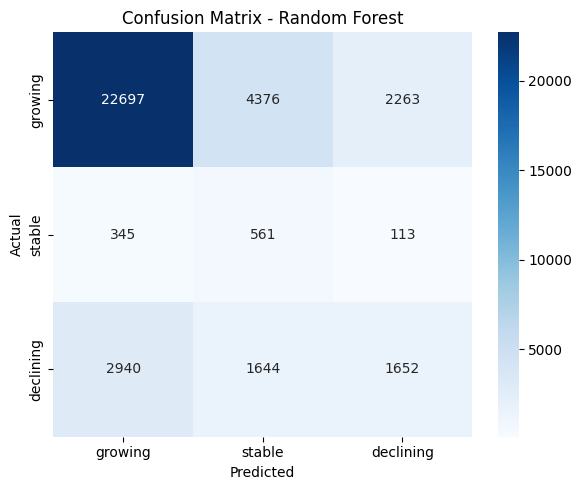

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_preds, labels=['growing', 'stable', 'declining'])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['growing', 'stable', 'declining'],
            yticklabels=['growing', 'stable', 'declining'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

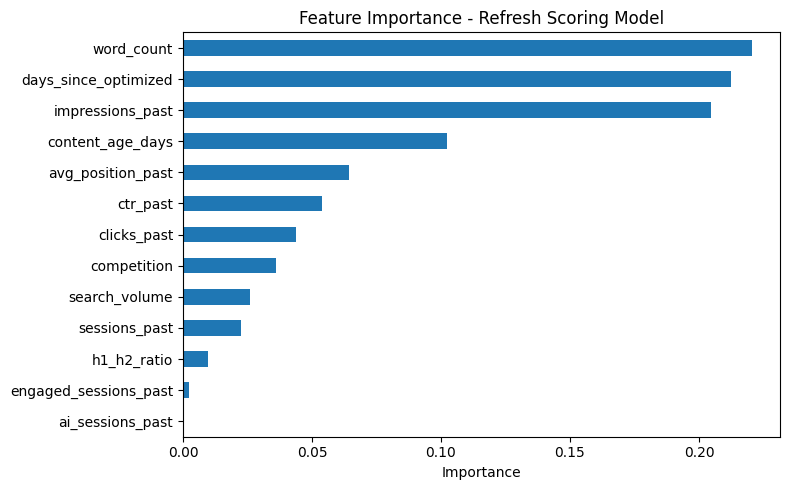

In [ ]:
# Feature importance chart
plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Feature Importance - Refresh Scoring Model')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

                       Model  Accuracy  Macro F1
0  Baseline (majority class)  0.801727  0.296651
1              Random Forest  0.680768  0.430045


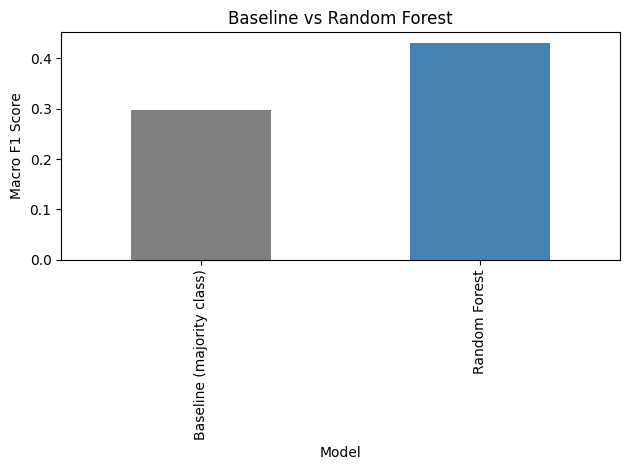

In [ ]:
# Baseline vs RF comparison (F1 macro)
from sklearn.metrics import f1_score

baseline_f1 = f1_score(y_test, baseline_preds, average='macro', zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, average='macro', zero_division=0)

comparison = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, baseline_preds), accuracy_score(y_test, rf_preds)],
    'Macro F1': [baseline_f1, rf_f1]
})
print(comparison)

comparison.plot(x='Model', y='Macro F1', kind='bar', legend=False, color=['gray', 'steelblue'])
plt.ylabel('Macro F1 Score')
plt.title('Baseline vs Random Forest')
plt.tight_layout()
plt.savefig('baseline_vs_rf.png', dpi=150)
plt.show()

In [ ]:
# Get prediction probabilities (not just class) for ranking
proba = rf.predict_proba(X_test)
class_order = rf.classes_
print(class_order)  # confirm order: e.g. ['declining', 'growing', 'stable']

['declining' 'growing' 'stable']


In [ ]:
# Build a results dataframe with content_hash_id + predictions + probabilities
results = model_df.iloc[test_idx].copy() if False else None

# Correct approach: use the test index from X_test directly
test_results = model_df.loc[X_test.index].copy()
test_results['predicted_label'] = rf_preds

# Add probability for "declining" as the priority score
declining_idx = list(class_order).index('declining')
test_results['declining_probability'] = proba[:, declining_idx]

# Sort by declining probability (highest = most urgent refresh candidate)
test_results = test_results.sort_values('declining_probability', ascending=False)

print(test_results[['content_hash_id', 'label', 'predicted_label', 'declining_probability',
                     'word_count', 'days_since_optimized', 'content_age_days']].head(20))

                 content_hash_id      label predicted_label  \
194620  content_3925670b13131a0e  declining       declining   
26937   content_86a9a01031a11a67  declining       declining   
66604   content_c2fa80d7529f80cb  declining       declining   
149160  content_69b4e417009a7b4b  declining       declining   
66579   content_66459d5be569d706  declining       declining   
146612  content_2d84e2eb33b9c8f1  declining       declining   
66544   content_a7bfb0d1be4d4739  declining       declining   
19120   content_f2de6875ff782c8e  declining       declining   
194647  content_8fa3aa3af31196aa  declining       declining   
21902   content_eeffff4525fb9fa0  declining       declining   
19177   content_e2b99016b2a75847  declining       declining   
66607   content_4aa2999abeda75ca  declining       declining   
26160   content_688484d1a4a832af  declining       declining   
147030  content_1fc689d37404c78d  declining       declining   
66611   content_14fe61c9272d3320  declining       decli

In [ ]:
# Fill any remaining NA values before applying the function
test_results['word_count'] = test_results['word_count'].fillna(0)
test_results['days_since_optimized'] = test_results['days_since_optimized'].fillna(0)
test_results['avg_position_past'] = test_results['avg_position_past'].fillna(100)
test_results['ctr_past'] = test_results['ctr_past'].fillna(0)

def assign_reason_code(row):
    reasons = []
    if row['days_since_optimized'] > 180:
        reasons.append('stale_content')
    if row['word_count'] < 500:
        reasons.append('thin_content')
    if row['avg_position_past'] > 30:
        reasons.append('low_ranking_position')
    if row['ctr_past'] < 0.01:
        reasons.append('low_ctr')
    if not reasons:
        reasons.append('review_recommended')
    return ', '.join(reasons)

test_results['reason_codes'] = test_results.apply(assign_reason_code, axis=1)

# Preview the top priority action list
action_engine = test_results[['content_hash_id', 'declining_probability', 'predicted_label',
                                'reason_codes', 'word_count', 'days_since_optimized', 'avg_position_past']].head(30)
print(action_engine.to_string())

                 content_hash_id  declining_probability predicted_label                                  reason_codes  word_count  days_since_optimized  avg_position_past
194620  content_3925670b13131a0e               0.936404       declining                 low_ranking_position, low_ctr        1871                 173.0               86.0
26937   content_86a9a01031a11a67               0.936404       declining                 low_ranking_position, low_ctr        1875                 173.0               86.0
66604   content_c2fa80d7529f80cb               0.934519       declining                 low_ranking_position, low_ctr        1833                 173.0               96.0
149160  content_69b4e417009a7b4b               0.932437       declining                 low_ranking_position, low_ctr        1985                 173.0               61.0
66579   content_66459d5be569d706               0.930548       declining                 low_ranking_position, low_ctr        1755                